In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df_bio = pd.read_csv('biometric.csv')

## Aadhaar Lifecycle Risk Index

In [3]:
df_bio.head()

,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,day
0,haryana,mahendragarh,123029,280,577,2025,3,1
1,bihar,madhepura,852121,144,369,2025,3,1
2,jammu and kashmir,punch,185101,643,1091,2025,3,1
3,bihar,bhojpur,802158,256,980,2025,3,1
4,tamil nadu,madurai,625514,271,815,2025,3,1


In [4]:
df_bio.head()

,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,day
0,haryana,mahendragarh,123029,280,577,2025,3,1
1,bihar,madhepura,852121,144,369,2025,3,1
2,jammu and kashmir,punch,185101,643,1091,2025,3,1
3,bihar,bhojpur,802158,256,980,2025,3,1
4,tamil nadu,madurai,625514,271,815,2025,3,1


## EDA

##### Reusable Functions

In [5]:
def histogram(df,col1,col2,xlabel , ylabel):
    plt.figure(figsize=(15,8))
    sns.set_style('darkgrid')
    sns.countplot(data=df , x =df[col1] , hue=df[col2])
    plt.xlabel(f"{xlabel}")
    plt.ylabel(f"{ylabel}")
    plt.xticks(rotation = 90)
    plt.show()
    plt.tight_layout()


def barplot(df,col1,col2,xlabel , ylabel):
    plt.figure(figsize=(15,8))
    sns.barplot(data = df , x = col1 , y=col2)
    plt.xlabel(f"{xlabel}")
    plt.ylabel(f"{ylabel}")
    plt.xticks(rotation = 90)
    plt.show()
    plt.tight_layout()


def scatterplot(df,col1,col2,xlabel , ylabel):
     plt.figure(figsize=(15,8))
     sns.scatterplot(data = df , x = col1 , y=col2)
     plt.xlabel(f"{xlabel}")
     plt.ylabel(f"{ylabel}")
     plt.xticks(rotation = 45)
     plt.show()
     plt.tight_layout()

def boxplot(df,col,xlabel , ylabel):
    plt.figure(figsize=(15,8))
    sns.set_style('darkgrid')
    sns.boxplot(data=df , x =df[col])
    plt.xlabel(f"{xlabel}")
    plt.ylabel(f"{ylabel}")
    plt.xticks(rotation = 90)
    plt.show()
    plt.tight_layout()

def heatmap(df):
    plt.figure(figsize=(15,10))
    sns.set_style("darkgrid")
    sns.heatmap(df.corr(numeric_only=True) , annot=True , cmap='coolwarm')
    plt.show()
    plt.tight_layout()

def kde(df,col1,xlabel , ylabel):
    plt.figure(figsize=(15,8))
    sns.set_style('darkgrid')
    sns.kdeplot(data=df , x =df[col1])
    plt.xlabel(f"{xlabel}")
    plt.ylabel(f"{ylabel}")
    plt.xticks(rotation = 90)
    plt.show()
    plt.tight_layout()

def histplot(df,col1,col2,xlabel , ylabel):
    plt.figure(figsize=(15,15))
    sns.set_style('darkgrid')
    sns.histplot(data=df , x =df[col1] , y=df[col2] , kde=True , palette="Set-2")
    plt.xlabel(f"{xlabel}")
    plt.ylabel(f"{ylabel}")
    plt.xticks(rotation = 90)
    plt.show()
    plt.tight_layout()

In [6]:
df_bio.head()   

,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,day
0,haryana,mahendragarh,123029,280,577,2025,3,1
1,bihar,madhepura,852121,144,369,2025,3,1
2,jammu and kashmir,punch,185101,643,1091,2025,3,1
3,bihar,bhojpur,802158,256,980,2025,3,1
4,tamil nadu,madurai,625514,271,815,2025,3,1


In [7]:
df_copy = df_bio.copy()

In [8]:
df_copy['total_biometric_age'] = df_copy['bio_age_5_17'] + df_copy['bio_age_17_']


## Which states generate the highest total biometric authentication demand?

### Gujarat , Maharastra , Madhya Pradesh , Bihar , Uttar Pradesh , Tamil Nadu , Rajasthan , Andhra Pradesh , Karnataka , West Bengal Generate the Most Demand and 
### Puducherry , sikkim , Daman and Diu and Dadra and Nagar Haveli , Andaman and Nicobar Islands , Lakshadweep , Ladakh , Jammu Kashmir , Chandigarh , Arunachal pradesh , Goa Generate Least Demand


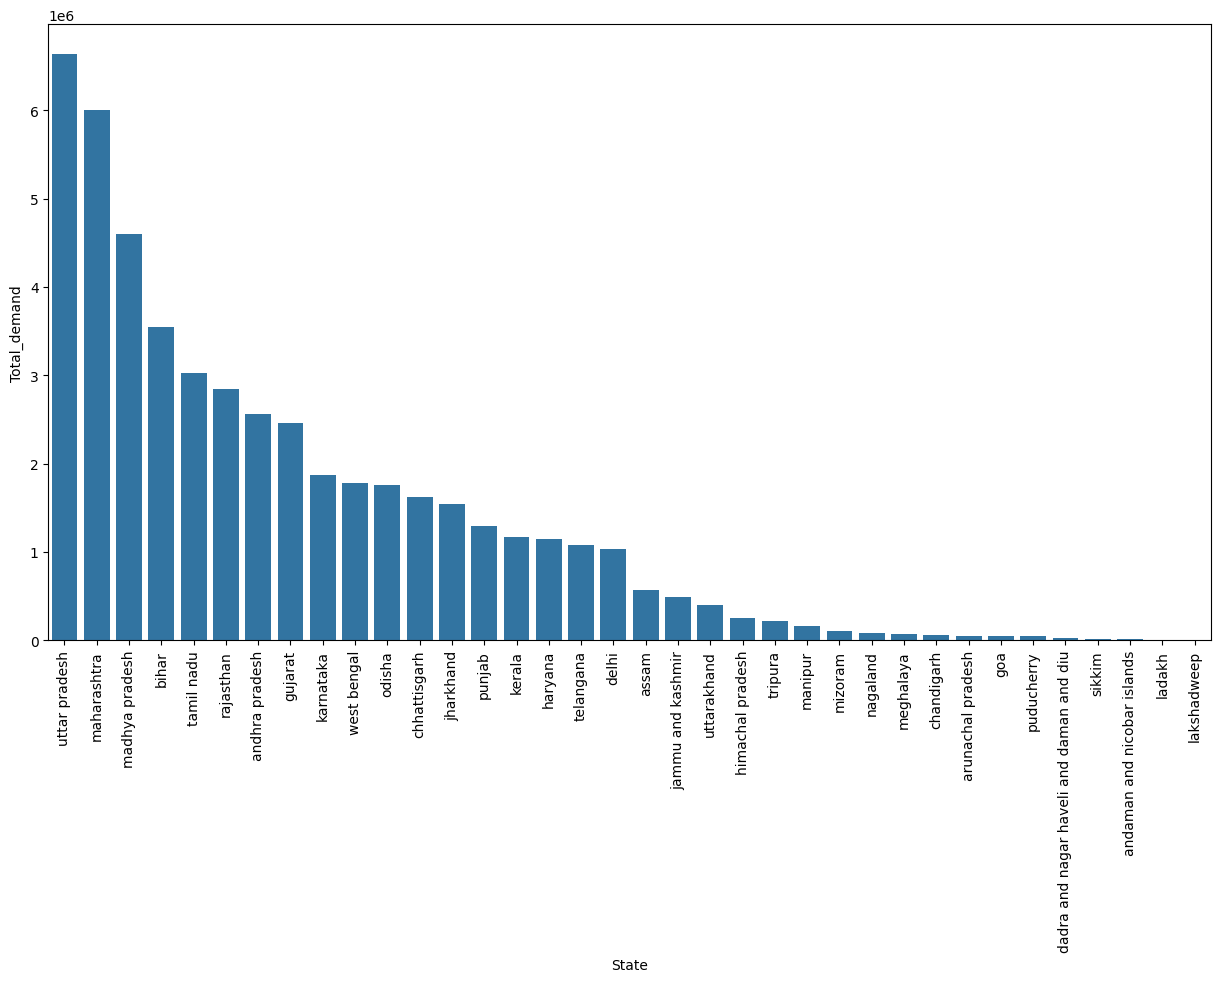

<Figure size 640x480 with 0 Axes>

In [9]:
df_total_bio_demand = df_copy.groupby('state')['total_biometric_age'].sum().sort_values(ascending=False).reset_index()
barplot(df_total_bio_demand , 'state' , 'total_biometric_age' , 'State' , 'Total_demand')

C:\Users\Yash0607\AppData\Local\Temp\ipykernel_9876\4165783143.py:61: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df , x =df[col1] , y=df[col2] , kde=True , palette="Set-2")


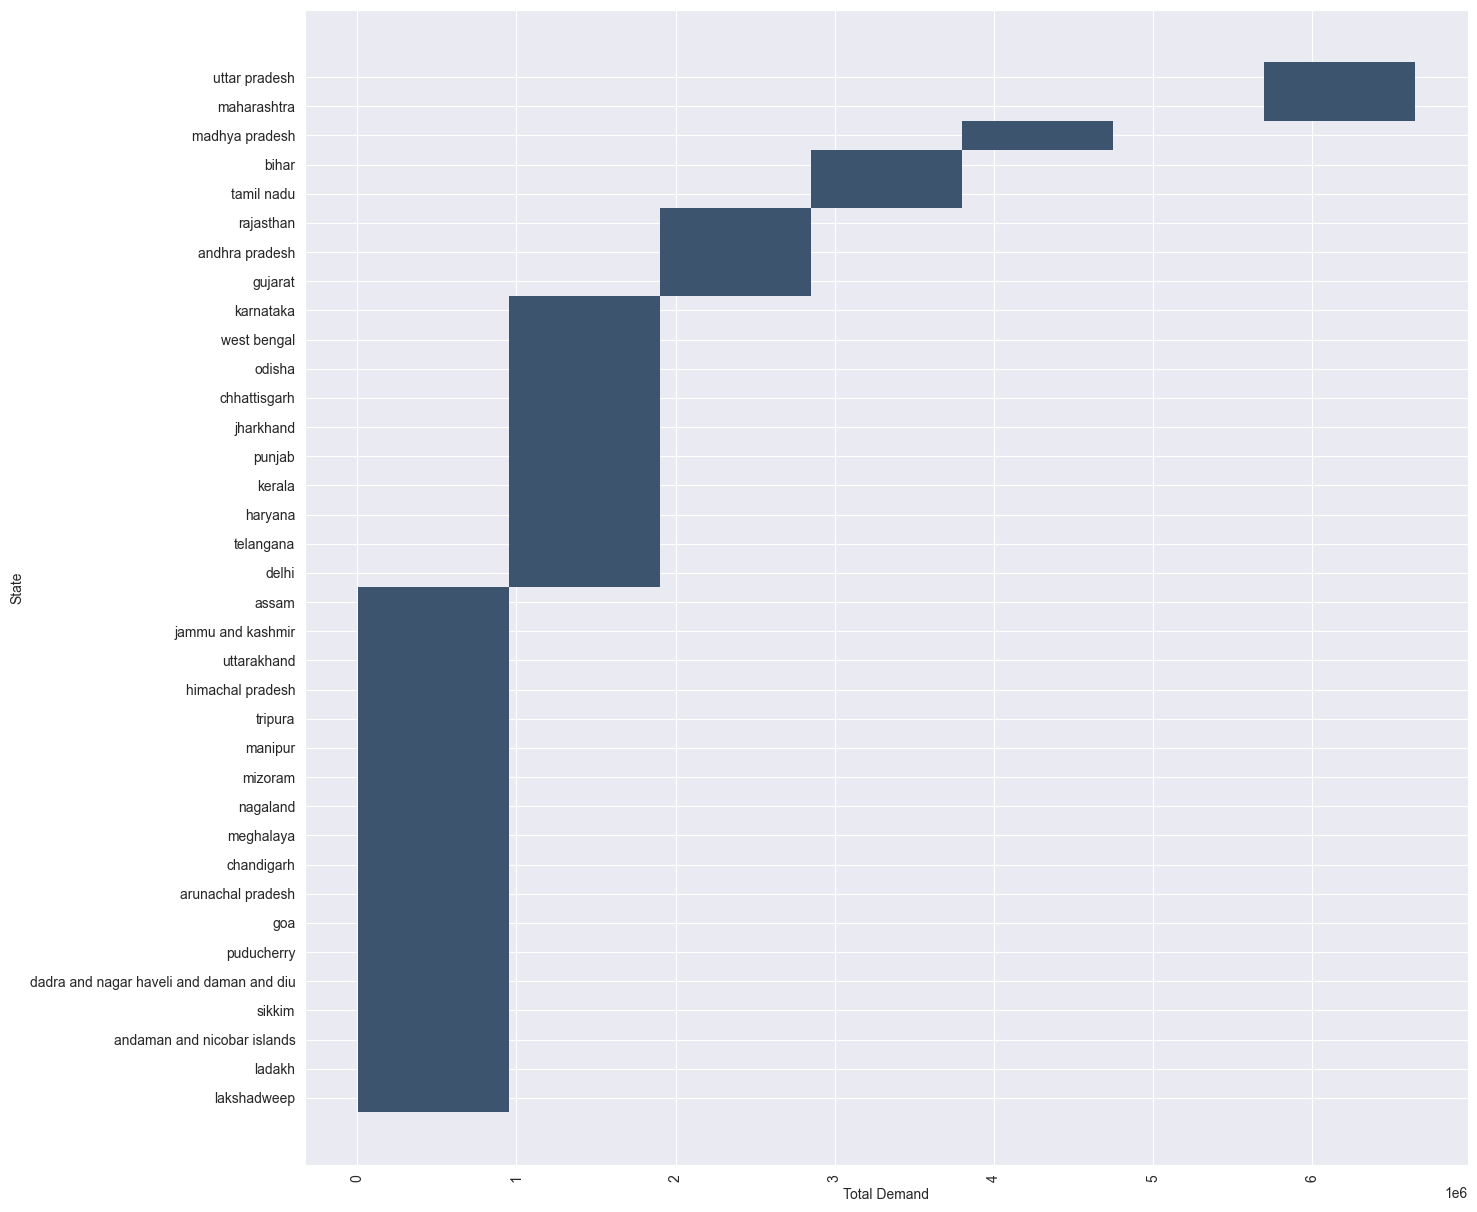

<Figure size 640x480 with 0 Axes>

In [10]:
histplot(df_total_bio_demand , "total_biometric_age" , "state" , "Total Demand" , "State")

In [11]:
df_total_bio_demand

,state,total_biometric_age
0,uttar pradesh,6643629
1,maharashtra,6002738
2,madhya pradesh,4601265
3,bihar,3543433
4,tamil nadu,3026489
5,rajasthan,2844034
6,andhra pradesh,2557511
7,gujarat,2455187
8,karnataka,1872811
9,west bengal,1776838


In [12]:
df_total_bio_demand.head(10)

,state,total_biometric_age
0,uttar pradesh,6643629
1,maharashtra,6002738
2,madhya pradesh,4601265
3,bihar,3543433
4,tamil nadu,3026489
5,rajasthan,2844034
6,andhra pradesh,2557511
7,gujarat,2455187
8,karnataka,1872811
9,west bengal,1776838


In [13]:
df_total_bio_demand.tail(10)

,state,total_biometric_age
26,meghalaya,66717
27,chandigarh,62765
28,arunachal pradesh,46607
29,goa,46230
30,puducherry,44628
31,dadra and nagar haveli and daman and diu,30293
32,sikkim,18306
33,andaman and nicobar islands,14611
34,ladakh,4140
35,lakshadweep,3313


### Which districts show consistently low Aadhaar enrollment for children (0–17)?

In [14]:
df_enrollment = pd.read_csv('enrollment.csv')
df_enrollment.head()

,state,district,pincode,age_0_5,age_5_17,age_18_greater,year,month,day
0,meghalaya,east khasi hills,793121,11,61,37,2025,3,2
1,karnataka,bengaluru urban,560043,14,33,39,2025,3,9
2,uttar pradesh,kanpur nagar,208001,29,82,12,2025,3,9
3,uttar pradesh,aligarh,202133,62,29,15,2025,3,9
4,karnataka,bengaluru urban,560016,14,16,21,2025,3,9


In [15]:
df_enrollment_copy = df_enrollment.copy()

In [16]:
df_enrollment_copy['total_minor_age'] = df_enrollment_copy['age_0_5'] + df_enrollment_copy['age_5_17']
df_enrollment_copy.drop(columns=['age_0_5' , 'age_5_17' , 'age_18_greater'],axis=1 , inplace=True)
df_enrollment_copy.head()

,state,district,pincode,year,month,day,total_minor_age
0,meghalaya,east khasi hills,793121,2025,3,2,72
1,karnataka,bengaluru urban,560043,2025,3,9,47
2,uttar pradesh,kanpur nagar,208001,2025,3,9,111
3,uttar pradesh,aligarh,202133,2025,3,9,91
4,karnataka,bengaluru urban,560016,2025,3,9,30


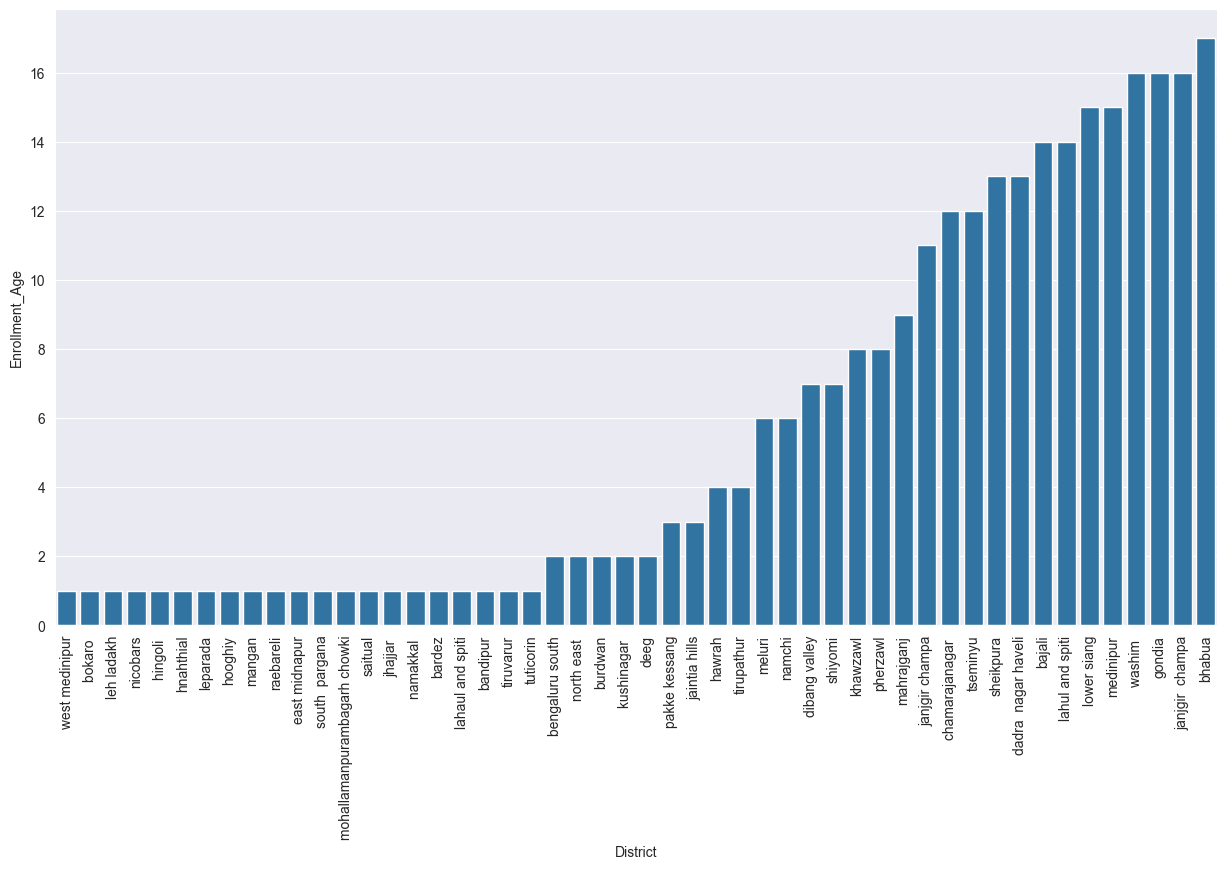

<Figure size 640x480 with 0 Axes>

In [17]:
df_low_enroll_minors = df_enrollment_copy.groupby('district')['total_minor_age'].sum().sort_values(ascending=True).reset_index()
barplot(df_low_enroll_minors.head(50) , "district" ,"total_minor_age","District","Enrollment_Age")

### bardez , lahul and spiti , leprada , south pargana , bokaro , leh ladakh , jhajjar , mangan , raebareily , nicobars , tuticorin and many more are the districts having low enrollment of children 

### uttar dinjapur , east khasi hills , bengaluru , gaya , hardoi , jaipur , bareily , hyderabad , bengaluru urban are among the districts wth high enrollment of children

In [18]:
df_low_enroll_minors.head(30)

,district,total_minor_age
0,west medinipur,1
1,bokaro,1
2,leh ladakh,1
3,nicobars,1
4,hingoli,1
5,hnahthial,1
6,leparada,1
7,hooghiy,1
8,mangan,1
9,raebareli,1


In [19]:
df_low_enroll_minors.tail(20)

,district,total_minor_age
928,uttar dinajpur,17277
929,east khasi hills,17548
930,bengaluru,17673
931,gaya,17689
932,hardoi,17818
933,jaipur,17930
934,east champaran,18161
935,bareilly,18632
936,shahjahanpur,18953
937,hyderabad,18966


## Input Features :
1) Coverage Risk
2) Data Instability Risk
3) Biometric Compliance Risk

## Target Feature : ALRI 

In [20]:
df_bio = pd.read_csv('biometric.csv')
df_enroll = pd.read_csv('enrollment.csv')
df_demographic = pd.read_csv('demographic.csv')

In [21]:
df_enroll['total_enrollment'] = df_enroll['age_0_5'] + df_enroll['age_5_17'] + df_enroll['age_18_greater']

In [22]:
df_enroll.sample(5)

,state,district,pincode,age_0_5,age_5_17,age_18_greater,year,month,day,total_enrollment
180369,tamil nadu,kanniyakumari,629201,1,0,0,2025,9,13,1
348777,west bengal,paschim medinipur,721165,3,2,0,2025,9,27,5
482427,west bengal,paschim medinipur,721126,1,1,0,2025,10,25,2
466246,assam,sonitpur,784501,2,0,0,2025,10,24,2
284305,west bengal,malda,732140,10,3,0,2025,9,22,13


### Child-Enrollment-ratio : Child Enrolment Ratio tells us what fraction of new Aadhaar enrolments are children (0–17 years) in a given region and month.

In [23]:
df_enroll['child_enroll_ratio']= (df_enroll['age_0_5'] + df_enroll['age_5_17']) / (df_enroll['total_enrollment']+1)
## +1 for not cases where it is dividing by 0.

In [24]:
df_enroll.sample(5)

,state,district,pincode,age_0_5,age_5_17,age_18_greater,year,month,day,total_enrollment,child_enroll_ratio
232865,madhya pradesh,chhatarpur,471411,5,2,0,2025,9,17,7,0.875000
309979,tamil nadu,tirunelveli,627423,1,1,0,2025,9,24,2,0.666667
217987,jharkhand,dhanbad,828306,4,3,0,2025,9,16,7,0.875000
11304,himachal pradesh,kangra,177103,1,0,0,2025,9,1,1,0.500000
51977,uttar pradesh,jalaun,285204,0,1,0,2025,9,4,1,0.500000


### Coverage Risk measures the risk that people — especially children — are missing Aadhaar enrolment in a region.

In [25]:
df_enroll['coverage_risk'] = 1-df_enroll['child_enroll_ratio']

In [26]:
df_enroll.sample(5)

,state,district,pincode,age_0_5,age_5_17,age_18_greater,year,month,day,total_enrollment,child_enroll_ratio,coverage_risk
18037,assam,lakhimpur,787032,9,4,1,2025,9,1,14,0.866667,0.133333
190345,bihar,madhepura,852112,0,1,0,2025,9,14,1,0.500000,0.500000
165689,tamil nadu,viluppuram,605652,0,1,0,2025,9,12,1,0.500000,0.500000
174225,telangana,medak,502248,0,1,0,2025,9,13,1,0.500000,0.500000
277372,odisha,rayagada,765021,1,0,0,2025,9,21,1,0.500000,0.500000


### Data Instability Risk measures how unstable Aadhaar demographic data is in a region over time.

In [27]:
df_demographic.sample(5)

,state,district,pincode,demo_age_5_17,demo_age_17_,year,month,day
248854,maharashtra,ratnagiri,416712,1,21,2025,11,1
19896,gujarat,kheda,387335,0,16,2025,9,3
113947,uttar pradesh,kaushambi,212204,3,21,2025,10,17
174624,rajasthan,jaipur,302021,2,22,2025,11,2
147410,tamil nadu,thanjavur,614205,1,5,2025,11,19


In [28]:
df_demographic['demo_total'] = df_demographic['demo_age_5_17'] + df_demographic['demo_age_17_']
df_demographic.sample(5)

,state,district,pincode,demo_age_5_17,demo_age_17_,year,month,day,demo_total
266592,telangana,khammam,507301,2,0,2025,11,8,2
91412,uttarakhand,almora,263676,0,1,2025,9,19,1
329205,gujarat,panchmahals,389232,0,9,2025,12,29,9
282790,rajasthan,barmer,344502,0,5,2025,11,25,5
369830,gujarat,vadodara,391105,2,10,2025,9,9,12


### Rolling volatility measures how much a value fluctuates over a short, moving time window.

In [29]:
df_demographic['demo_volatility'] = (
    df_demographic.groupby(['state','district','pincode'])['demo_total']
      .rolling(3) 
      .std()      # rolling formulae involves std
      .reset_index(drop=True , level=[0,1,2]) # for only row_id
)
df_demographic.sample(10)

,state,district,pincode,demo_age_5_17,demo_age_17_,year,month,day,demo_total,demo_volatility
298411,andhra pradesh,ananthapur,515871,1,7,2025,11,28,8,2.516611
302514,gujarat,surat,394163,0,2,2025,12,22,2,1.527525
104911,odisha,baleshwar,756166,0,2,2025,10,16,2,1.527525
164806,chhattisgarh,sarangarhbilaigarh,493338,2,17,2025,12,4,19,5.033223
5416,gujarat,gandhinagar,382610,0,8,2025,9,1,8,NaN
286931,tamil nadu,tenkasi,627811,0,5,2025,11,29,5,3.055050
242214,tamil nadu,villupuram,604303,2,10,2025,10,27,12,4.509250
215666,odisha,jharsuguda,768234,0,3,2025,11,10,3,1.154701
249768,odisha,jharsuguda,768219,1,5,2025,10,31,6,0.577350
396917,maharashtra,raigarh,402201,1,3,2025,9,15,4,1.000000


In [30]:
pd.DataFrame(df_demographic.groupby(['state','district','pincode'])['demo_total'].rolling(3).std())

demo_total
state                       district       pincode                   
andaman and nicobar islands andamans       744101  51259          NaN
                                                   82291          NaN
                                                   171122    1.527525
                                                   197558    2.000000
                                                   254773    3.605551
...                                                               ...
west bengal                 west midnapore 721517  319546    5.507571
                                                   383046    7.023769
                                                   384539    7.094599
                                           721641  149644         NaN
                                                   202047         NaN

[418705 rows x 1 columns]

In [31]:
df_demographic.isnull().sum() # null values are present , so we will do imputation and fill the values with 0

state                  0
district               0
pincode                0
demo_age_5_17          0
demo_age_17_           0
year                   0
month                  0
day                    0
demo_total             0
demo_volatility    56227
dtype: int64

In [32]:
df_demographic['demo_volatility'] = df_demographic['demo_volatility'].fillna(0)
upper_cap = df_demographic['demo_volatility'].quantile(0.99)
df_demographic['demo_volatility'] = df_demographic['demo_volatility'].clip(upper=upper_cap)

In [33]:
df_demographic.isnull().sum() # no null 

state              0
district           0
pincode            0
demo_age_5_17      0
demo_age_17_       0
year               0
month              0
day                0
demo_total         0
demo_volatility    0
dtype: int64

In [34]:
df_demographic.sample(5)

,state,district,pincode,demo_age_5_17,demo_age_17_,year,month,day,demo_total,demo_volatility
236890,andhra pradesh,nizamabad,503122,0,1,2025,12,1,1,0.577350
30209,chhattisgarh,mungeli,495335,0,1,2025,9,7,1,0.000000
182268,odisha,baleswar,756059,0,1,2025,12,6,1,2.000000
157885,assam,nalbari,781334,2,1,2025,10,29,3,4.041452
159407,odisha,bhadrak,756101,0,7,2025,10,30,7,2.886751


### 

### Biometric Compliance Risk measures the risk that people—especially children—will face Aadhaar authentication failures in the future because mandatory biometric updates are not happening properly.

In [35]:
df_bio.sample(5)

,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,day
200534,west bengal,north parganas,700157,7,2,2025,9,5
178928,haryana,jhajjar,124501,3,1,2025,9,4
83066,gujarat,patan,384221,85,59,2025,6,1
442479,west bengal,nadia,741164,1,7,2025,9,17
280223,telangana,khammam,507115,13,4,2025,9,9


In [36]:
df_bio['bio_child_total'] = df_bio['bio_age_5_17']  + df_bio['bio_age_17_']
df_bio['bio_child_ratio'] = (df_bio['bio_age_5_17'] )/ (df_bio['bio_child_total']+1)
# df_bio.sample(5)

In [37]:
df_bio['bio_compliance_risk'] = 1-df_bio['bio_child_ratio']
# df_bio.sample(5)

In [38]:
df_bio.isnull().sum() # no nan values

state                  0
district               0
pincode                0
bio_age_5_17           0
bio_age_17_            0
year                   0
month                  0
day                    0
bio_child_total        0
bio_child_ratio        0
bio_compliance_risk    0
dtype: int64

In [39]:
df_bio.sample(5)

,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,day,bio_child_total,bio_child_ratio,bio_compliance_risk
115492,karnataka,udupi,576114,1,1,2025,9,1,2,0.333333,0.666667
356327,rajasthan,jaipur,303007,26,5,2025,9,13,31,0.812500,0.187500
360910,tamil nadu,namakkal,637210,2,4,2025,9,13,6,0.285714,0.714286
274261,west bengal,koch bihar,735224,1,0,2025,9,9,1,0.500000,0.500000
67200,punjab,jalandhar,144022,163,313,2025,6,1,476,0.341719,0.658281


In [40]:
df_demographic.sample(5)

,state,district,pincode,demo_age_5_17,demo_age_17_,year,month,day,demo_total,demo_volatility
270900,uttar pradesh,jhansi,284401,0,4,2025,12,18,4,12.342339
273644,karnataka,bengaluru,560036,1,2,2025,12,18,3,13.527749
214651,odisha,sundargarh,770019,0,1,2025,11,11,1,1.527525
311392,uttar pradesh,lucknow,226201,0,2,2025,12,23,2,1.527525
102757,west bengal,haora,711405,0,11,2025,10,15,11,5.291503


In [41]:
df_enroll.sample(5)

,state,district,pincode,age_0_5,age_5_17,age_18_greater,year,month,day,total_enrollment,child_enroll_ratio,coverage_risk
337860,uttar pradesh,etawah,206242,2,6,0,2025,9,26,8,0.888889,0.111111
177105,west bengal,kolkata,700042,0,2,0,2025,9,13,2,0.666667,0.333333
78165,andhra pradesh,vizianagaram,532123,1,0,0,2025,9,6,1,0.500000,0.500000
442110,andhra pradesh,krishna,520002,1,0,0,2025,10,19,1,0.500000,0.500000
37490,rajasthan,jalor,343021,4,0,0,2025,9,3,4,0.800000,0.200000


### Inner Join data on Common Columns

In [42]:
df_risk = (
    df_enroll[
        ['state','district','pincode','year','month','day','coverage_risk']
    ]
    .merge(
        df_demographic[
            ['state','district','pincode','year','month','day','demo_volatility']
        ],
        on=['state','district','pincode','year','month','day'],
        how='inner'
    )
    .merge(
        df_bio[
            ['state','district','pincode','year','month','day','bio_compliance_risk']
        ],
        on=['state','district','pincode','year','month','day'],
        how='inner'
    )
)

In [43]:
df_risk

,state,district,pincode,year,month,day,coverage_risk,demo_volatility,bio_compliance_risk
0,haryana,gurgaon,122002,2025,4,1,0.115385,477.192582,0.529412
1,rajasthan,jaipur,302012,2025,4,1,0.021978,477.192582,0.669484
2,uttar pradesh,baghpat,250611,2025,4,1,0.034296,477.192582,0.320450
3,gujarat,rajkot,360002,2025,4,1,0.113402,477.192582,0.498050
4,maharashtra,nandurbar,425412,2025,4,1,0.038869,477.192582,0.673626
...,...,...,...,...,...,...,...,...,...
95876,jharkhand,seraikelakharsawan,831013,2025,9,19,0.250000,4.041452,1.000000
95877,jharkhand,seraikelakharsawan,833220,2025,9,19,0.500000,14.742230,0.695652
95878,karnataka,yadgir,585214,2025,9,19,0.250000,1.527525,0.800000
95879,karnataka,yadgir,585220,2025,9,19,0.500000,1.154701,1.000000


In [44]:
df_risk['ALRI'] = (
    0.30*df_risk['coverage_risk'] +
    0.40*df_risk['demo_volatility'] +
    0.30*df_risk['bio_compliance_risk']
)

In [45]:
df_risk['ALRI_next_month'] = (
    df_risk.groupby(['state','district','pincode'])['ALRI'].shift(-1)
)

In [46]:
df_risk.drop(columns=['state','district','year','month' , 'day' , 'pincode'],axis=1,inplace=True)

In [47]:
# df_risk = df_risk.to_csv('final_df.csv', index=False)

In [48]:
df_risk.sample(10)

,coverage_risk,demo_volatility,bio_compliance_risk,ALRI,ALRI_next_month
84149,0.333333,2.886751,0.800000,1.494701,1.389978
44732,0.166667,13.892444,0.425532,5.734637,0.185357
348,0.100000,4.932883,0.600000,2.183153,0.166667
86494,0.500000,0.000000,1.000000,0.450000,1.267824
93152,0.166667,14.433757,0.371429,5.934931,6.023503
25193,0.500000,477.192582,1.000000,191.327033,191.072327
69507,0.333333,10.440307,0.370370,4.387234,3.801097
89053,0.500000,5.567764,0.666667,2.577106,NaN
66034,0.500000,3.055050,0.444444,1.505354,1.530000
28021,0.250000,477.192582,0.600000,191.132033,5.581984


In [49]:
# normalize demo_volatility
v = np.log1p(df_risk['demo_volatility'])
v  = df_risk['demo_volatility']
df_risk['demo_volatility'] = ((v-v.min())/(v.max()-v.min())) # min-max normalized


In [50]:
# df_risk['demo_volatility'].isnull().sum() # no nans and nulls

In [51]:
# df_risk.sample(10)

In [52]:
# df_risk.describe()

### Target Feature : ALRI
ALRI = weighted combination of multiple risk signals
| Risk                      | What it captures                 |
| ------------------------- | -------------------------------- |
| Coverage_Risk             | People missing Aadhaar           |
| Data_Instability_Risk     | Aadhaar data becoming unreliable |
| Biometric_Compliance_Risk | Future authentication failures   |


### See Outliers

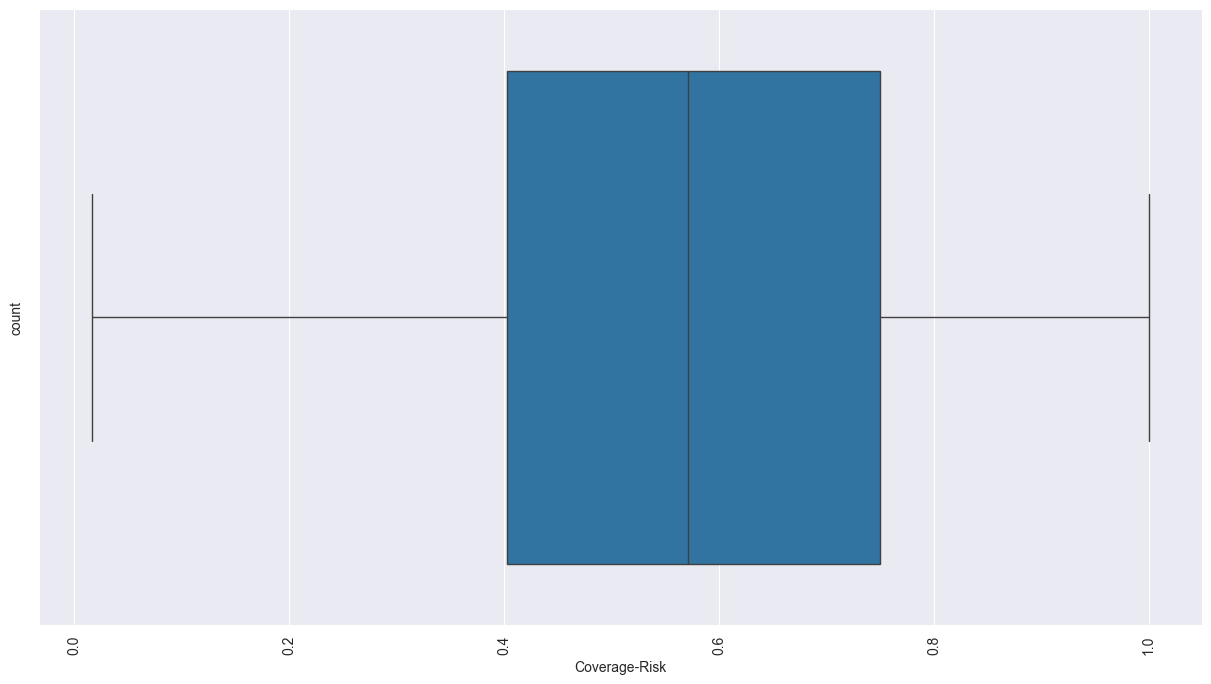

<Figure size 640x480 with 0 Axes>

In [53]:
boxplot(df_risk , 'bio_compliance_risk' , 'Coverage-Risk' , 'count')

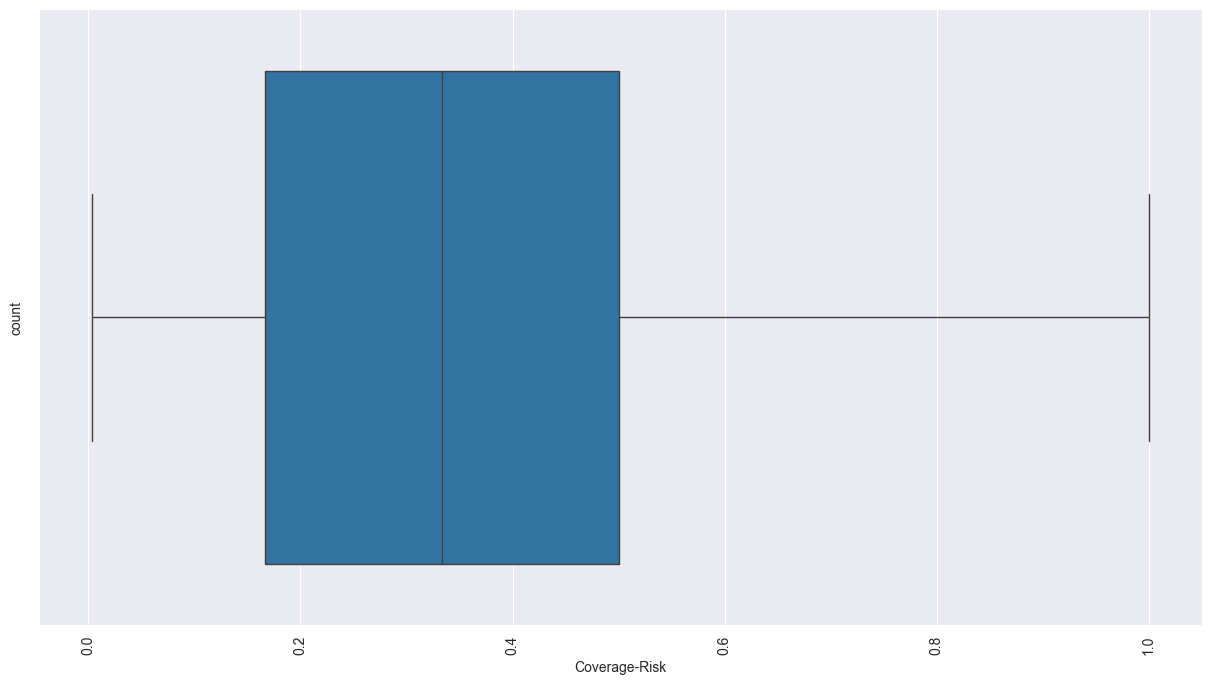

<Figure size 640x480 with 0 Axes>

In [54]:
boxplot(df_risk , 'coverage_risk' , 'Coverage-Risk' , 'count')

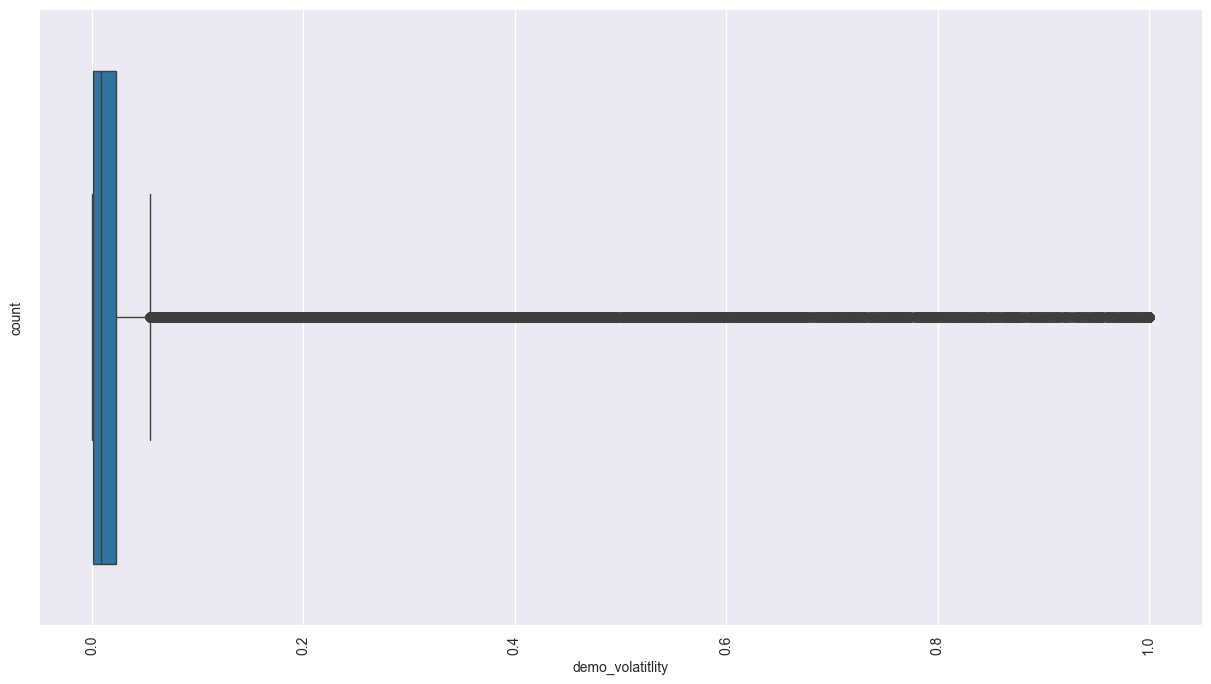

<Figure size 640x480 with 0 Axes>

In [55]:
boxplot(df_risk , 'demo_volatility' , 'demo_volatitlity' , 'count')

In [56]:
df_risk['ALRI_next_month'].value_counts()

ALRI_next_month
0.450000      667
0.300000      538
0.250000      419
0.350000      409
0.400000      366
             ... 
2.923991        1
6.233976        1
0.590940        1
3.504273        1
191.040348      1
Name: count, Length: 55051, dtype: int64

In [57]:
df_risk = df_risk[df_risk['ALRI_next_month'].notna()]
df_risk

,coverage_risk,demo_volatility,bio_compliance_risk,ALRI,ALRI_next_month
0,0.115385,1.000000,0.529412,191.070472,0.428571
1,0.021978,1.000000,0.669484,191.084471,191.071603
2,0.034296,1.000000,0.320450,190.983456,191.008388
3,0.113402,1.000000,0.498050,191.060468,191.040348
4,0.038869,1.000000,0.673626,191.090781,191.091015
...,...,...,...,...,...
95843,0.034483,0.001210,0.500000,0.391285,0.391285
95844,0.034483,0.001210,0.500000,0.391285,0.391285
95845,0.034483,0.001210,0.500000,0.391285,0.391285
95849,0.500000,0.007259,0.666667,1.735641,1.835641


In [58]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Loading and preprocessing data...")

# ========== LOAD DATA ==========
df_bio = pd.read_csv('biometric.csv')
df_enroll = pd.read_csv('enrollment.csv')
df_demographic = pd.read_csv('demographic.csv')

# ========== ENROLLMENT FEATURES ==========
df_enroll['total_enrollment'] = df_enroll['age_0_5'] + df_enroll['age_5_17'] + df_enroll['age_18_greater']
df_enroll['child_enroll_ratio'] = (df_enroll['age_0_5'] + df_enroll['age_5_17']) / (df_enroll['total_enrollment'] + 1)
df_enroll['coverage_risk'] = 1 - df_enroll['child_enroll_ratio']
df_enroll['infant_ratio'] = df_enroll['age_0_5'] / (df_enroll['total_enrollment'] + 1)
df_enroll['youth_ratio'] = df_enroll['age_5_17'] / (df_enroll['total_enrollment'] + 1)
df_enroll['adult_ratio'] = df_enroll['age_18_greater'] / (df_enroll['total_enrollment'] + 1)

# ========== DEMOGRAPHIC FEATURES ==========
df_demographic['demo_total'] = df_demographic['demo_age_5_17'] + df_demographic['demo_age_17_']

# Calculate rolling volatility
df_demographic['demo_volatility'] = (
    df_demographic.groupby(['state', 'district', 'pincode'])['demo_total']
    .rolling(3)
    .std()
    .reset_index(drop=True, level=[0, 1, 2])
)
df_demographic['demo_volatility'] = df_demographic['demo_volatility'].fillna(0)
upper_cap = df_demographic['demo_volatility'].quantile(0.99)
df_demographic['demo_volatility'] = df_demographic['demo_volatility'].clip(upper=upper_cap)

# Normalize demo_volatility
v = df_demographic['demo_volatility']
df_demographic['demo_volatility_norm'] = (v - v.min()) / (v.max() - v.min() + 1e-10)

df_demographic['demo_child_ratio'] = df_demographic['demo_age_5_17'] / (df_demographic['demo_total'] + 1)
df_demographic['demo_trend'] = df_demographic.groupby(['state', 'district', 'pincode'])['demo_total'].diff()
df_demographic['demo_trend'] = df_demographic['demo_trend'].fillna(0)

# ========== BIOMETRIC FEATURES ==========
df_bio['bio_child_total'] = df_bio['bio_age_5_17'] + df_bio['bio_age_17_']
df_bio['bio_child_ratio'] = df_bio['bio_age_5_17'] / (df_bio['bio_child_total'] + 1)
df_bio['bio_compliance_risk'] = 1 - df_bio['bio_child_ratio']
df_bio['bio_update_rate'] = df_bio['bio_child_total'] / (df_bio['bio_age_5_17'] + df_bio['bio_age_17_'] + 1)

# ========== MERGE DATASETS ==========
df_risk = (
    df_enroll[['state', 'district', 'pincode', 'year', 'month', 'day', 
               'coverage_risk', 'total_enrollment', 'infant_ratio', 'youth_ratio', 'adult_ratio']]
    .merge(
        df_demographic[['state', 'district', 'pincode', 'year', 'month', 'day', 
                       'demo_volatility_norm', 'demo_child_ratio', 'demo_trend', 'demo_total']],
        on=['state', 'district', 'pincode', 'year', 'month', 'day'],
        how='inner'
    )
    .merge(
        df_bio[['state', 'district', 'pincode', 'year', 'month', 'day', 
               'bio_compliance_risk', 'bio_update_rate', 'bio_child_total']],
        on=['state', 'district', 'pincode', 'year', 'month', 'day'],
        how='inner'
    )
)

# ========== CALCULATE CURRENT ALRI ==========
df_risk['ALRI'] = (
    0.30 * df_risk['coverage_risk'] +
    0.40 * df_risk['demo_volatility_norm'] +
    0.30 * df_risk['bio_compliance_risk']
)

# ========== SORT BY TIME ==========
df_risk = df_risk.sort_values(['state', 'district', 'pincode', 'year', 'month', 'day']).reset_index(drop=True)

# ========== CREATE TARGET ==========
df_risk['ALRI_next_month'] = df_risk.groupby(['state', 'district', 'pincode'])['ALRI'].shift(-1)

# ========== FEATURE ENGINEERING ==========
le_state = LabelEncoder()
le_district = LabelEncoder()

df_risk['state_encoded'] = le_state.fit_transform(df_risk['state'])
df_risk['district_encoded'] = le_district.fit_transform(df_risk['district'])

# Temporal features
df_risk['month_sin'] = np.sin(2 * np.pi * df_risk['month'] / 12)
df_risk['month_cos'] = np.cos(2 * np.pi * df_risk['month'] / 12)

# Interaction features
df_risk['coverage_bio_interaction'] = df_risk['coverage_risk'] * df_risk['bio_compliance_risk']

# Remove rows without target
df_risk = df_risk[df_risk['ALRI_next_month'].notna()].reset_index(drop=True)

print(f"Total records: {len(df_risk)}")

# ========== CREATE SEQUENCES FOR LSTM ==========
def create_sequences(df, sequence_length=3):
    """
    Create sequences for LSTM training
    Each sequence contains 'sequence_length' time steps
    """
    feature_cols = [
        'coverage_risk', 'demo_volatility_norm', 'bio_compliance_risk',
        'total_enrollment', 'infant_ratio', 'youth_ratio', 'adult_ratio',
        'demo_child_ratio', 'demo_trend', 'demo_total',
        'bio_update_rate', 'bio_child_total',
        'month_sin', 'month_cos', 'coverage_bio_interaction',
        'state_encoded', 'district_encoded', 'ALRI'
    ]
    
    sequences = []
    targets = []
    metadata = []
    
    # Group by location
    grouped = df.groupby(['state', 'district', 'pincode'])
    
    for name, group in grouped:
        group = group.sort_values(['year', 'month', 'day']).reset_index(drop=True)
        
        # Only create sequences if we have enough data points
        if len(group) >= sequence_length + 1:
            for i in range(len(group) - sequence_length):
                # Get sequence of features
                seq = group[feature_cols].iloc[i:i+sequence_length].values
                target = group['ALRI_next_month'].iloc[i+sequence_length-1]
                
                if not np.isnan(target):
                    sequences.append(seq)
                    targets.append(target)
                    metadata.append({
                        'state': name[0],
                        'district': name[1],
                        'pincode': name[2]
                    })
    
    return np.array(sequences), np.array(targets), metadata

# Create sequences
SEQUENCE_LENGTH = 3  # Look at 3 months of history
print(f"\nCreating sequences with length {SEQUENCE_LENGTH}...")
X, y, metadata = create_sequences(df_risk, sequence_length=SEQUENCE_LENGTH)

print(f"Sequences shape: {X.shape}")
print(f"Targets shape: {y.shape}")

# ========== TRAIN-TEST SPLIT ==========
# Use 80% for training, 20% for testing (maintain temporal order)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\nTrain sequences: {X_train.shape}")
print(f"Test sequences: {X_test.shape}")

# ========== SCALE FEATURES ==========
# Reshape for scaling
n_samples_train, n_timesteps, n_features = X_train.shape
X_train_reshaped = X_train.reshape(-1, n_features)
X_test_reshaped = X_test.reshape(-1, n_features)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

# Reshape back to 3D
X_train_scaled = X_train_scaled.reshape(n_samples_train, n_timesteps, n_features)
X_test_scaled = X_test_scaled.reshape(-1, n_timesteps, n_features)

# ========== BUILD LSTM MODEL ==========
print("\nBuilding LSTM model...")

model = Sequential([
    # First LSTM layer with return sequences
    Bidirectional(LSTM(128, return_sequences=True, activation='tanh'), 
                  input_shape=(SEQUENCE_LENGTH, n_features)),
    Dropout(0.3),
    
    # Second LSTM layer
    Bidirectional(LSTM(64, return_sequences=False, activation='tanh')),
    Dropout(0.3),
    
    # Dense layers
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # Output layer
])

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(model.summary())

# ========== CALLBACKS ==========
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# ========== TRAIN MODEL ==========
print("\nTraining LSTM model...")
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# ========== EVALUATE MODEL ==========
print("\n" + "="*50)
print("EVALUATING MODEL")
print("="*50)

y_pred = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\nLSTM Model Results:")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"R²:   {r2:.4f}")

# ========== SAMPLE PREDICTIONS ==========
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

sample_indices = np.random.choice(len(y_test), min(10, len(y_test)), replace=False)
comparison_df = pd.DataFrame({
    'Actual': y_test[sample_indices],
    'Predicted': y_pred[sample_indices],
    'Error': np.abs(y_test[sample_indices] - y_pred[sample_indices])
})
print(comparison_df.to_string(index=False))

# ========== TRAINING HISTORY ==========
print("\n" + "="*50)
print("TRAINING HISTORY (Last 5 epochs)")
print("="*50)
history_df = pd.DataFrame(history.history)
print(history_df.tail())

# ========== SAVE MODEL ==========
model.save('alri_lstm_model.h5')
print("\nModel saved as 'alri_lstm_model.h5'")

# Save scaler for future use
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved as 'scaler.pkl'")

print("\n" + "="*50)
print("TRAINING COMPLETE!")
print("="*50)

C:\Users\Yash0607\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Loading and preprocessing data...
Total records: 74364

Creating sequences with length 3...
Sequences shape: (28185, 3, 18)
Targets shape: (28185,)

Train sequences: (22548, 3, 18)
Test sequences: (5637, 3, 18)

Building LSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 3, 256)         │       150,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,553 (1.22 MB)

 Trainable params: 319,553 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

None

Training LSTM model...
Epoch 1/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0116 - mae: 0.0784 - val_loss: 0.0094 - val_mae: 0.0723 - learning_rate: 0.0010
Epoch 2/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0094 - mae: 0.0715 - val_loss: 0.0099 - val_mae: 0.0765 - learning_rate: 0.0010
Epoch 3/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0092 - mae: 0.0707 - val_loss: 0.0094 - val_mae: 0.0731 - learning_rate: 0.0010
Epoch 4/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0091 - mae: 0.0702 - val_loss: 0.0096 - val_mae: 0.0749 - learning_rate: 0.0010
Epoch 5/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0090 - mae: 0.0698 - val_loss: 0.0094 - val_mae: 0.0741 - learning_rate: 0.0010
Epoch 6/100
558/564 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0091 - mae: 0.0700
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0089 - mae: 0.0696 - val_loss: 0.0094 - val_ma


LSTM Model Results:
MAE:  0.0815
RMSE: 0.1040
MSE:  0.0108
R²:   0.1863

SAMPLE PREDICTIONS
  Actual  Predicted    Error
0.211676   0.277220 0.065543
0.167606   0.375684 0.208078
0.243467   0.257889 0.014422
0.120423   0.189958 0.069536
0.375000   0.358653 0.016347
0.270000   0.269405 0.000595
0.420211   0.318901 0.101309
0.168081   0.312821 0.144740
0.097403   0.274288 0.176885
0.279757   0.293883 0.014126

TRAINING HISTORY (Last 5 epochs)
        loss       mae  val_loss   val_mae  learning_rate
16  0.008137  0.066151  0.009554  0.072753       0.000125
17  0.008056  0.065961  0.009686  0.073155       0.000125
18  0.008090  0.066035  0.009641  0.073007       0.000125
19  0.008084  0.065987  0.009820  0.074084       0.000125
20  0.008057  0.065874  0.009826  0.073779       0.000125

Model saved as 'alri_lstm_model.h5'
Scaler saved as 'scaler.pkl'

TRAINING COMPLETE!
